In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# se carga el dataset desde tu Google Drive
df = pd.read_csv('/content/drive/MyDrive/Delfin_Cardiometabolico/framingham.csv')
# Exploración inicial
print("\nForma del dataset:", df.shape)
print("\nTipo de datos:")
print(df.dtypes)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nEstadsiticas descriptivas:")
print(df.describe())


Forma del dataset: (4240, 16)

Tipo de datos:
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Primeras 5 filas:
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentH

In [ ]:
# Verificar datos nulos en el dataset
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [ ]:
# === TRATAMIENTO DE VALORES NULOS (SEMANA 2) ===

# 1. Imputación por Mediana para las variables clínicas numéricas
columnas_mediana = ['glucose', 'totChol', 'cigsPerDay', 'BMI', 'heartRate']
for col in columnas_mediana:
    df[col] = df[col].fillna(df[col].median())

# 2. Imputación por Moda para variables categóricas / niveles
columnas_moda = ['education', 'BPMeds']
for col in columnas_moda:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Verificación final de limpieza
print("¡Limpieza completada con éxito!")
print("\nNuevos valores nulos por columna:")
print(df.isnull().sum())

¡Limpieza completada con éxito!

Nuevos valores nulos por columna:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


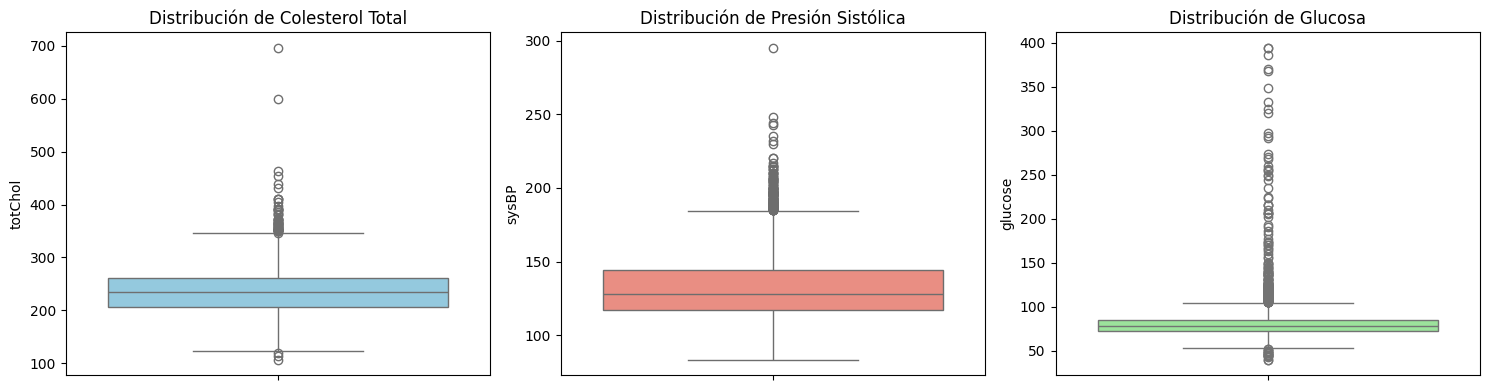

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el lienzo para los gráficos
plt.figure(figsize=(15, 4))

# 1. Gráfico para el Colesterol Total
plt.subplot(1, 3, 1)
sns.boxplot(y=df['totChol'], color='skyblue')
plt.title('Distribución de Colesterol Total')

# 2. Gráfico para la Presión Sistólica
plt.subplot(1, 3, 2)
sns.boxplot(y=df['sysBP'], color='salmon')
plt.title('Distribución de Presión Sistólica')

# 3. Gráfico para la Glucosa
plt.subplot(1, 3, 3)
sns.boxplot(y=df['glucose'], color='lightgreen')
plt.title('Distribución de Glucosa')

plt.tight_layout()
plt.show()

DESGLOSE TECNICO Y CIENTIFICO

In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Identificar las columnas numéricas continuas que tienen los outliers
columnas_a_escalar = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

# 2. Inicializar el Escalador Robusto
scaler = RobustScaler()

# 3. Aplicar el escalado a las columnas seleccionadas
df[columnas_a_escalar] = scaler.fit_transform(df[columnas_a_escalar])

# 4. Mostrar cómo quedaron los primeros datos ya normalizados
print("¡Dataset normalizado y escalado con éxito para Machine Learning!")
df[columnas_a_escalar].head()

¡Dataset normalizado y escalado con éxito para Machine Learning!


,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,-0.714286,0.00,-0.696429,-0.814815,-0.800000,0.316852,0.333333,-0.076923
1,-0.214286,0.00,0.285714,-0.259259,-0.066667,0.672048,1.333333,-0.153846
2,-0.071429,1.00,0.196429,-0.018519,-0.133333,-0.012109,0.000000,-0.615385
3,0.857143,1.50,-0.160714,0.814815,0.866667,0.641776,-0.666667,1.923077
4,-0.214286,1.15,0.910714,0.074074,0.133333,-0.464178,0.666667,0.538462


In [ ]:
# Actividad 1: Descriptores estadísticos del dataset
df_estadisticos = df.describe().T
df_estadisticos

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.000000,0.000000,0.0,1.000000,1.000000
age,4240.0,0.041442,0.612353,-1.214286,-0.500000,0.0,0.500000,1.500000
education,4240.0,1.955189,1.018522,1.000000,1.000000,2.0,3.000000,4.000000
currentSmoker,4240.0,0.494104,0.500024,0.000000,0.000000,0.0,1.000000,1.000000
cigsPerDay,4240.0,0.447217,0.595239,0.000000,0.000000,0.0,1.000000,3.500000
BPMeds,4240.0,0.029245,0.168513,0.000000,0.000000,0.0,0.000000,1.000000
prevalentStroke,4240.0,0.005896,0.076569,0.000000,0.000000,0.0,0.000000,1.000000
prevalentHyp,4240.0,0.310613,0.462799,0.000000,0.000000,0.0,1.000000,1.000000
diabetes,4240.0,0.025708,0.158280,0.000000,0.000000,0.0,0.000000,1.000000
totChol,4240.0,0.047637,0.791580,-2.267857,-0.500000,0.0,0.500000,8.250000


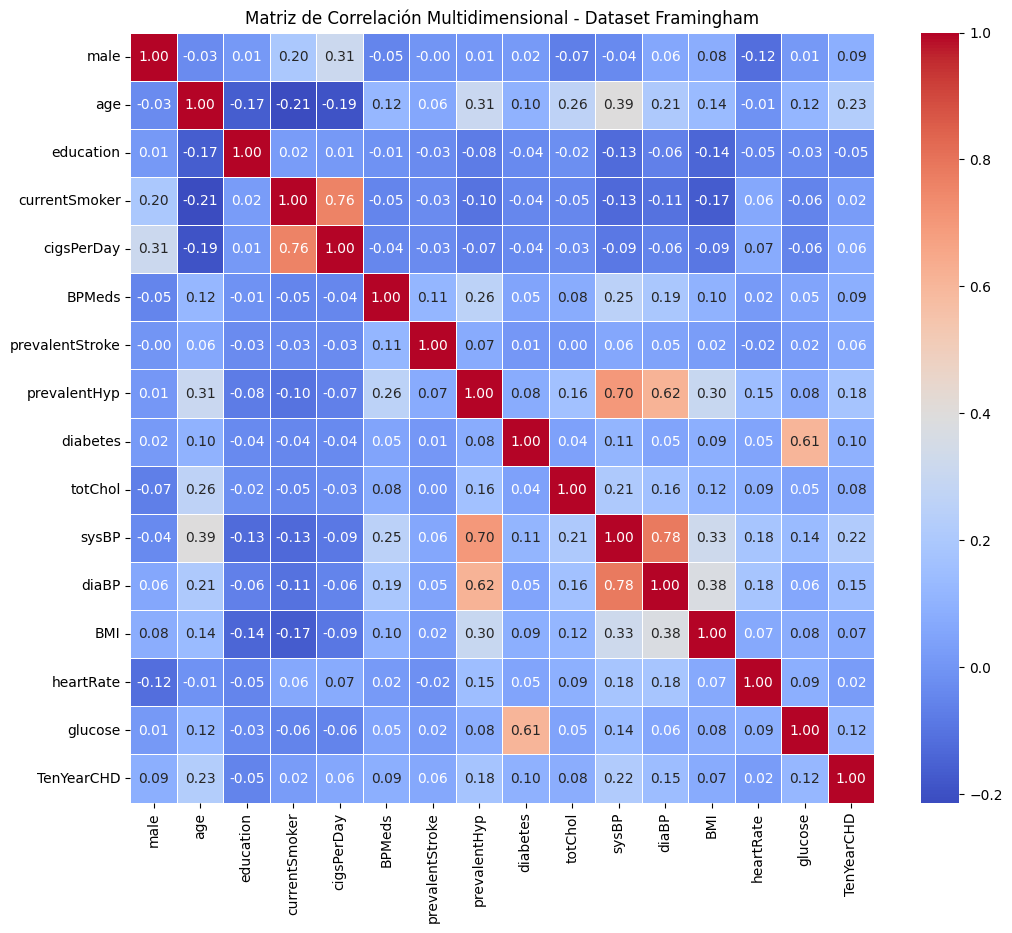

In [ ]:
# Actividad 2: Mapa de calor de correlación
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Multidimensional - Dataset Framingham')
plt.show()